#### Building a Neural Network from Scratch

In [6]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt

In [7]:
%cd sample_data
%ls

[Errno 2] No such file or directory: 'sample_data'
/content/sample_data
anscombe.json*                mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [8]:
## Explore The Data
data = pd.read_csv("./mnist_train_small.csv")
data.head(3)

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
data = np.array(data)
m, n = data.shape # get number of rows and number of element in 2D array
np.random.shuffle(data) # WHY THIS

data_dev = data[0: 1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1: m]

data_train = data[1000: m].T
X_train = data_train[1: n] / 255.0
Y_train = data_train[0]

In [10]:
X_train.shape # (NLine, NColumn)

(784, 18999)

In [11]:
Y_train

array([2, 5, 0, ..., 3, 1, 8])

In [12]:
# Init The Hyper Parameter
nbr_neural_hidden_layer = 10
def init_param():
    # n is number of columns in dataset
    W_1 = np.random.rand(10, 784) - 0.5
    B_1 = np.random.rand(10, 1) - 0.5

    W_2 = np.random.rand(10, 10) - 0.5
    B_2 = np.random.rand(10, 1) - 0.5
    return W_1, B_1, W_2, B_2
init_param()

# ForWard Propagation
def ReLU(Z):
    return np.maximum(Z, 0)

def softMaX(Z):
    # Subtracting the max for numerical stability
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W_1, B_1, W_2, B_2, X):
    # Calculate Z_1 = W_1 * A_0 + B_1
    Z_1 = W_1.dot(X) + B_1
    A_1 = ReLU(Z_1)
    
    # Calculate Z_2 = W_2 * A_1 + B_2
    Z_2 = W_2.dot(A_1) + B_2
    A_2 = softMaX(Z_2)
    return Z_1, A_1, Z_2, A_2

# BackWard Propagation
def on_hot_code(Y):
    Y_len = len(Y)
    new_Y = np.zeros(shape=(10, Y_len), dtype=np.uint8)
    
    for i in range(Y_len):
        new_Y[Y[i]][i] = 1
    return new_Y

def ReLU_deriv(Z):
    return Z > 0 # Element Big Then 0 Converted TO 1 ELSE TO 0

def backward_prop(Z_1, A_1, Z_2, A_2, W_1, W_2, X, Y):
    Y_new = on_hot_code(Y)
    # print("OPERATION A_2: ", A_2.shape)
    # print("OPERATION: Y_new", Y_new.shape)
    # print("Y = ", Y)
    # print("A_2: ", A_2)
    ### FOR OUTPUR LAYER
    dZ_2 = A_2 - Y_new
    dW_2 = (1/m) * dZ_2.dot(A_1.T)
    dB_2 = (1 / m) * np.sum(dZ_2, axis=1, keepdims=True)

    ### FOR HIDDEN LAYER
    dZ_1 = W_2.T.dot(dZ_2) * ReLU_deriv(Z_1)
    dW_1 = (1 / m) * dZ_1.dot(X.T) # where X is A_0
    dB_1 = (1 / m) * np.sum(dZ_1, axis=1, keepdims=True)
    
    return dW_2, dB_2, dW_1, dB_1


# Update Params
def update_params(W_1, W_2, B_1, B_2, dW_1, dW_2, dB_1, dB_2, alpha):
    W_2 = W_2 - (alpha * dW_2)
    B_2 = B_2 - (alpha * dB_2)
    W_1 = W_1 - (alpha * dW_1)
    B_1 = B_1 - (alpha * dB_1)

    return W_2, B_2, W_1, B_1


In [13]:
# Model Predict A_2 = [0.01, 0.02, 0.85, 0.02, ...]
# Means Model Predict 2 Because The High Value is 0.85
def get_prediction(A_2):
    return np.argmax(A_2, axis=0)

def get_accuracy(predictions, Y):
    return np.sum(Y == predictions) / Y.size

def gradient_descent(X, Y, alpha, epochs):
    W_1, B_1, W_2, B_2 = init_param()
    # print(new_Y)
    for i in range(epochs):
        # print(X.shape)
        # print("W_1.shape: ", W_1.shape)
        # print("B_1.shape: ", B_1.shape)
        # print("W_2.shape: ", W_2.shape)
        # print("B_2.shape: ", B_2.shape)
        # print("X.shape: ", X.shape)
        # print("Y.shape: ", Y.shape)
        Z_1, A_1, Z_2, A_2 = forward_prop(W_1, B_1, W_2, B_2, X)
        # print("A_1: ", A_1.shape)
        dW_2, dB_2, dW_1, dB_1 = backward_prop(Z_1, A_1, Z_2, A_2, W_1, W_2, X, Y)
        W_2, B_2, W_1, B_1 = update_params(W_1, W_2, B_1, B_2, dW_1, dW_2, dB_1, dB_2, alpha)
        if (i % 1 == 0):
            # Get Prediction and Accuray
            print("Iteration: ", i)
            predicted_value = get_prediction(A_2=A_2)
            print("Predicted Value is: ", predicted_value)
            print("Y Value is: ", Y)

            accuracy = get_accuracy(predictions=predicted_value, Y=Y)
            print("Accuracy is: ", accuracy)
    return W_2, W_1, B_1, B_2

In [14]:
# Train Model on Traing Set
W_2, W_1, B_1, B_2 = gradient_descent(X=X_train, Y=Y_train, alpha=0.01, epochs=4000)

Iteration:  0
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.10505816095583978
Iteration:  1
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.10547923574924996
Iteration:  2
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.10595294489183642
Iteration:  3
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.10705826622453814
Iteration:  4
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.10900573714406021
Iteration:  5
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.1101636928259382
Iteration:  6
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.1122690667929891
Iteration:  7
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Value is:  [2 5 0 ... 3 1 8]
Accuracy is:  0.11426917206168746
Iteration:  8
Predicted Value is:  [5 5 9 ... 3 3 3]
Y Val

~82% accuracy on training set.

In [15]:
%ls

anscombe.json*                mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [16]:
# Save Weights and Bias
np.savez("model.npz", W1=W_1, B1=B_1, W2=W_2, B2=B_2)
# data = np.load("./model.npz", allow_pickle=True)

# W_1, B_1 = data["W1"], data["B1"]
# W_2, B_2 = data["W2"], data["B2"]

In [17]:
import matplotlib.pyplot as plt

In [18]:
print(X_train.shape)
print(X_dev.shape)

(784, 18999)
(784, 1000)


In [19]:
one_image = data_train.T[3][1:].reshape(784, 1)
real_value = data_train.T[3][0:1]

Number Of Example in Test Set:  (1,)
Prediction:  [5]
Real Prediction:  [5]
Number Of Correct Prediction 1 Of 1
Accuray:  1.0


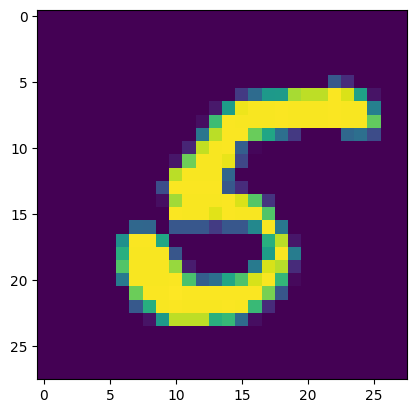

In [20]:
# Test Model in Traing Test
def make_predictions(X, W_2, W_1, B_1, B_2):
    _, _, _, A_2 = forward_prop(W_1, B_1, W_2, B_2, X)
    predictions = get_prediction(A_2)
    return predictions

def test_predictions(W_1, B_1, W_2, B_2, X, Y):
    print("Number Of Example in Test Set: ", Y.shape)
    predictions = make_predictions(X, W_2, W_1, B_1, B_2)
    accuray = get_accuracy(predictions=predictions, Y=Y)
    print("Prediction: ", predictions[0:10])
    print("Real Prediction: ", Y[0:10])
    print(f"Number Of Correct Prediction {np.sum(Y == predictions)} Of {len(Y)}")
    print("Accuray: ", accuray)
    
    # Show Image
    img = X.reshape(28, 28) * 255
    plt.imshow(img)

test_predictions(W_1=W_1, B_1=B_1, W_2=W_2, B_2=B_2, X=one_image, Y=real_value)
# test_predictions(W_1=W_1, B_1=B_1, W_2=W_2, B_2=B_2, X=X_dev, Y=Y_dev)

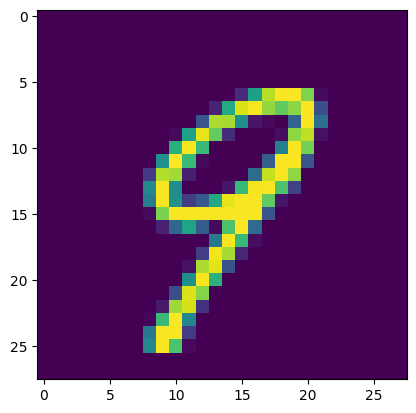

In [21]:
# Code Example Of Displaying An Image
first_image = X_dev.T[0].reshape(28, 28) * 255
plt.imshow(first_image)